In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [4]:
df = pd.read_csv("UNR-IDD (1).csv")

print(df.shape)
df.head()

(37411, 34)


,Switch ID,Port Number,Received Packets,Received Bytes,Sent Bytes,Sent Packets,Port alive Duration (S),Packets Rx Dropped,Packets Tx Dropped,Packets Rx Errors,...,Unknown Load/Latest,Latest bytes counter,is_valid,Table ID,Active Flow Entries,Packets Looked Up,Packets Matched,Max Size,Label,Binary Label
0,of:000000000000000c,Port#:1,132,9181,6311853,238,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
1,of:000000000000000c,Port#:2,187,6304498,15713,171,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
2,of:000000000000000c,Port#:3,235,6311567,8030,58,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
3,of:000000000000000c,Port#:4,59,7878,16439,182,46,0,0,0,...,0,0,True,0,9,767,688,-1,TCP-SYN,Attack
4,of:000000000000000a,Port#:1,188,6304547,16497,183,46,0,0,0,...,0,0,True,0,7,489,403,-1,TCP-SYN,Attack


In [5]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

In [6]:
#INSPECTING THE DATA SET
df.info()

df.describe()

df['Label'].value_counts()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37411 entries, 0 to 37410
Data columns (total 34 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   Switch ID                      37411 non-null  object
 1   Port Number                    37411 non-null  object
 2   Received Packets               37411 non-null  int64 
 3   Received Bytes                 37411 non-null  int64 
 4   Sent Bytes                     37411 non-null  int64 
 5   Sent Packets                   37411 non-null  int64 
 6   Port alive Duration (S)        37411 non-null  int64 
 7   Packets Rx Dropped             37411 non-null  int64 
 8   Packets Tx Dropped             37411 non-null  int64 
 9   Packets Rx Errors              37411 non-null  int64 
 10  Packets Tx Errors              37411 non-null  int64 
 11  Delta Received Packets         37411 non-null  int64 
 12  Delta Received Bytes           37411 non-null  int64 
 13  D

Label
PortScan     9500
TCP-SYN      9081
Blackhole    8420
Diversion    5615
Normal       3773
Overflow     1022
Name: count, dtype: int64

In [7]:
#FOR BINARY LABELS
df['Binary Label'].value_counts()

Binary Label
Attack    33638
Normal     3773
Name: count, dtype: int64

In [8]:
#DATA PROCESSING
#1. IDENTIFICATION OF CATEGORICAL COLUMN
categorical_cols = df.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['Switch ID', 'Port Number', 'Label', 'Binary Label'], dtype='object')


In [10]:
#NCODING CATEGORICAL FEATURES
encoders = {}

for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])

    encoders[col] = le

In [11]:
#DROPING CONSTANT FEATURES
constant_cols = [
    col for col in df.columns
    if df[col].nunique() == 1
]

print(constant_cols)

df.drop(columns=constant_cols, inplace=True)

['Packets Rx Dropped', 'Packets Tx Dropped', 'Packets Rx Errors', 'Packets Tx Errors', 'Delta Packets Rx Dropped', ' Delta Packets Tx Dropped', 'Delta Packets Rx Errors', 'Delta Packets Tx Errors', 'is_valid', 'Table ID', 'Max Size']


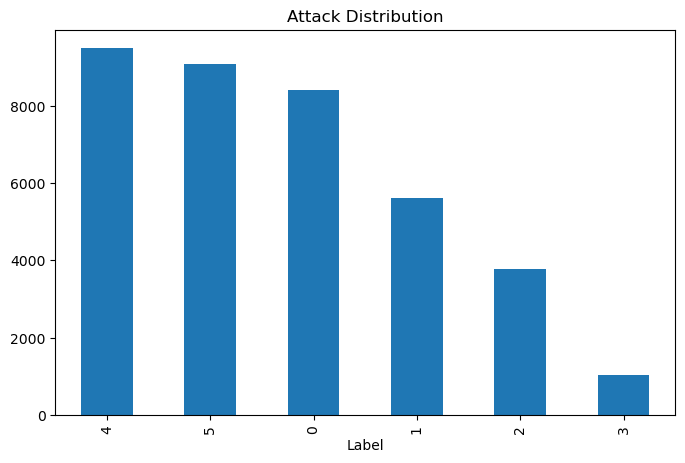

In [12]:
#EXPLORATORY DATA ANALYSIS
#Label Distribution
plt.figure(figsize=(8,5))

df['Label'].value_counts().plot(
    kind='bar'
)

plt.title("Attack Distribution")
plt.show()

In [13]:
#NUMERIC FEATURES
numeric_cols = df.select_dtypes(
    include=np.number
).columns

print(numeric_cols)

Index(['Switch ID', 'Port Number', 'Received Packets', 'Received Bytes',
       'Sent Bytes', 'Sent Packets', 'Port alive Duration (S)',
       'Delta Received Packets', 'Delta Received Bytes', 'Delta Sent Bytes',
       'Delta Sent Packets', 'Delta Port alive Duration (S)',
       'Connection Point', 'Total Load/Rate', 'Total Load/Latest',
       'Unknown Load/Rate', 'Unknown Load/Latest', 'Latest bytes counter',
       'Active Flow Entries', 'Packets Looked Up', 'Packets Matched', 'Label',
       'Binary Label'],
      dtype='object')


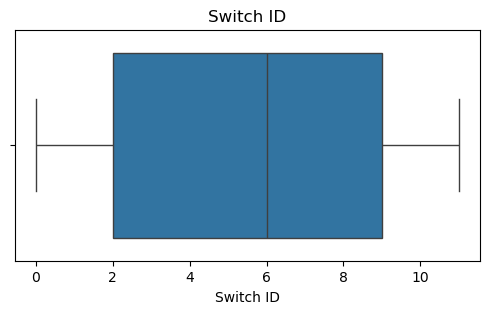

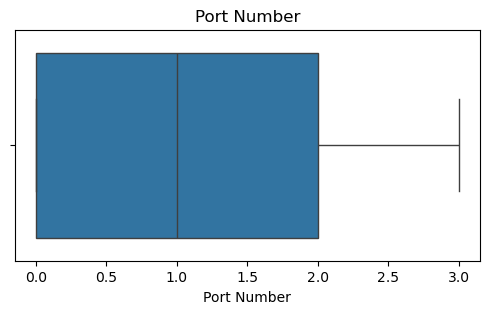

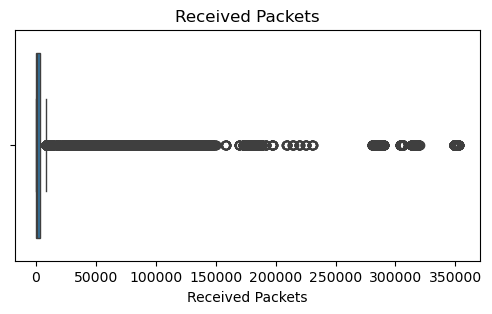

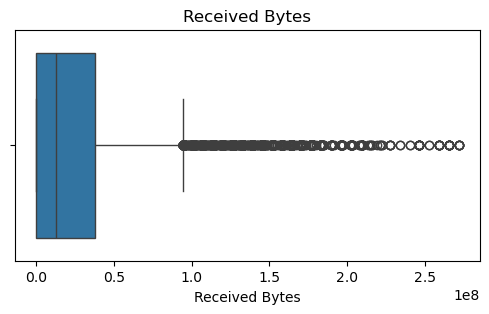

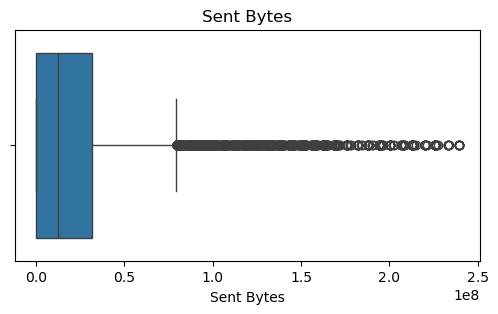

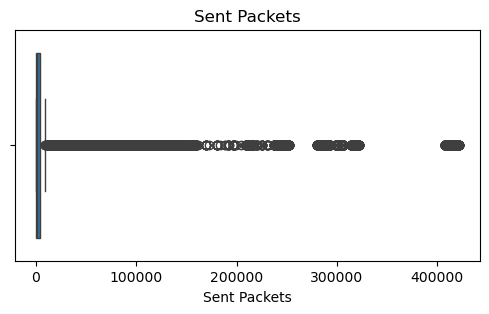

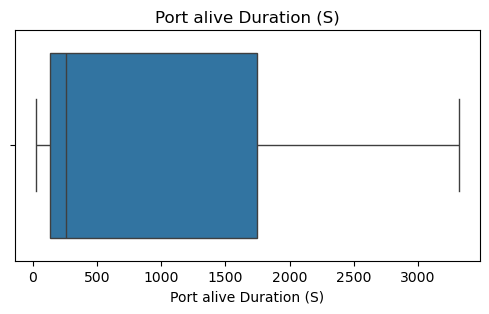

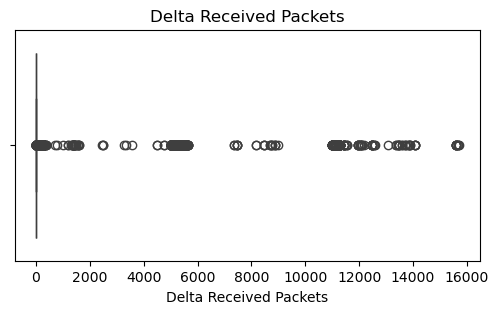

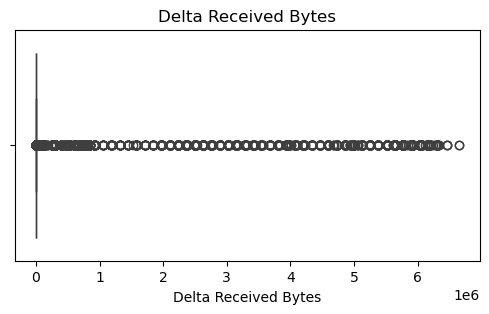

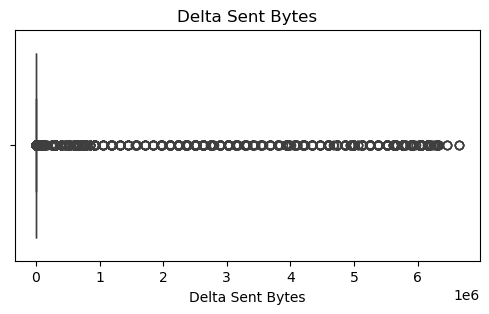

In [14]:
#BOXPLOTS
for col in numeric_cols[:10]:

    plt.figure(figsize=(6,3))

    sns.boxplot(x=df[col])

    plt.title(col)

    plt.show()

In [15]:
#IQR OUTLIER DETECTION
def detect_outliers_iqr(data):

    outliers = {}

    for col in data.columns:

        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)

        IQR = Q3 - Q1

        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR

        count = (
            (data[col] < lower) |
            (data[col] > upper)
        ).sum()

        outliers[col] = count

    return outliers

outliers = detect_outliers_iqr(
    df[numeric_cols]
)

outliers


{'Switch ID': np.int64(0),
 'Port Number': np.int64(0),
 'Received Packets': np.int64(4710),
 'Received Bytes': np.int64(2629),
 'Sent Bytes': np.int64(3358),
 'Sent Packets': np.int64(5657),
 'Port alive Duration (S)': np.int64(0),
 'Delta Received Packets': np.int64(9172),
 'Delta Received Bytes': np.int64(9123),
 'Delta Sent Bytes': np.int64(8509),
 'Delta Sent Packets': np.int64(8522),
 'Delta Port alive Duration (S)': np.int64(5876),
 'Connection Point': np.int64(0),
 'Total Load/Rate': np.int64(5263),
 'Total Load/Latest': np.int64(6689),
 'Unknown Load/Rate': np.int64(5263),
 'Unknown Load/Latest': np.int64(6689),
 'Latest bytes counter': np.int64(5263),
 'Active Flow Entries': np.int64(2192),
 'Packets Looked Up': np.int64(7844),
 'Packets Matched': np.int64(7860),
 'Label': np.int64(0),
 'Binary Label': np.int64(3773)}

In [16]:
#MULTI CLASS CLASIFICATION 
#FEAtures AND TARGET 
X = df.drop(
    columns=['Label', 'Binary Label']
)

y = df['Label']

In [ ]:
#TRAIN/VALIDATION /TEST

In [17]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

In [18]:
#FEATURE SCALING 
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(
    X_train
)

X_val_scaled = scaler.transform(
    X_val
)

X_test_scaled = scaler.transform(
    X_test
)

In [19]:
#HYPERPARAMETER TUNING
rf = RandomForestClassifier(
    random_state=42
)

param_grid = {
    'n_estimators':[100,200],
    'max_depth':[10,20,None],
    'min_samples_split':[2,5]
}

grid = GridSearchCV(
    rf,
    param_grid,
    cv=3,
    scoring='accuracy',
    n_jobs=-1
)

grid.fit(
    X_train_scaled,
    y_train
)

print(grid.best_params_)

{'max_depth': None, 'min_samples_split': 2, 'n_estimators': 200}


In [20]:
#BEST MODEL
best_rf = grid.best_estimator_

In [21]:
#VALIDATION EVALUATION
val_pred = best_rf.predict(
    X_val_scaled
)

print(
    accuracy_score(
        y_val,
        val_pred
    )
)

print(
    classification_report(
        y_val,
        val_pred
    )
)

0.9422665716322167
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1263
           1       1.00      0.97      0.98       842
           2       1.00      1.00      1.00       566
           3       0.97      0.77      0.86       154
           4       0.90      0.91      0.91      1425
           5       0.88      0.92      0.90      1362

    accuracy                           0.94      5612
   macro avg       0.96      0.93      0.94      5612
weighted avg       0.94      0.94      0.94      5612



In [22]:
#TEST EVALUATION 
test_pred = best_rf.predict(
    X_test_scaled
)

print(
    accuracy_score(
        y_test,
        test_pred
    )
)

print(
    classification_report(
        y_test,
        test_pred
    )
)

0.9485032074126871
              precision    recall  f1-score   support

           0       0.99      0.98      0.99      1263
           1       1.00      0.98      0.99       843
           2       1.00      1.00      1.00       566
           3       1.00      0.71      0.83       153
           4       0.91      0.92      0.92      1425
           5       0.89      0.93      0.91      1362

    accuracy                           0.95      5612
   macro avg       0.97      0.92      0.94      5612
weighted avg       0.95      0.95      0.95      5612



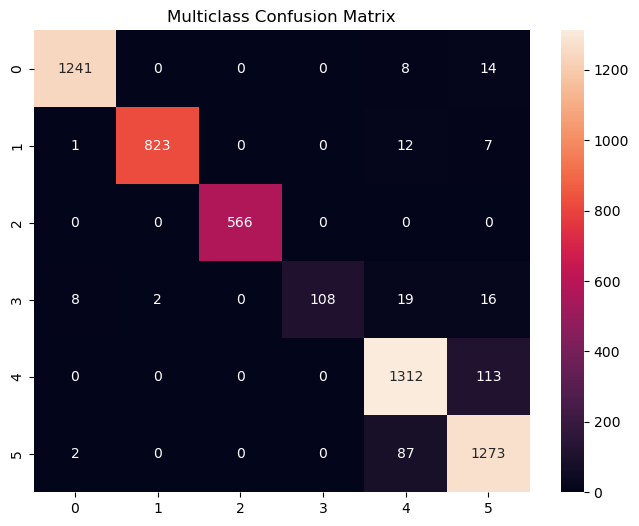

In [23]:
#CONFUSION MATRIX
cm = confusion_matrix(
    y_test,
    test_pred
)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d'
)

plt.title(
    "Multiclass Confusion Matrix"
)

plt.show()

In [24]:
#BINARY CLASSIFICATION
#BINARY FEATURES/ LABELS
X_bin = df.drop(
    columns=['Label', 'Binary Label']
)

y_bin = df['Binary Label']

In [25]:
#BINARY SPLITS
X_train_b, X_temp_b, y_train_b, y_temp_b = train_test_split(
    X_bin,
    y_bin,
    test_size=0.30,
    random_state=42,
    stratify=y_bin
)

X_val_b, X_test_b, y_val_b, y_test_b = train_test_split(
    X_temp_b,
    y_temp_b,
    test_size=0.50,
    random_state=42,
    stratify=y_temp_b
)

In [26]:
#SCALLING 
scaler_bin = StandardScaler()

X_train_b = scaler_bin.fit_transform(
    X_train_b
)

X_val_b = scaler_bin.transform(
    X_val_b
)

X_test_b = scaler_bin.transform(
    X_test_b
)

In [27]:
#TRAINING BINARY MODEL
rf_binary = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

rf_binary.fit(
    X_train_b,
    y_train_b
)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [28]:
#BINARY VALIDATION TEST
pred_val_b = rf_binary.predict(
    X_val_b
)

print(
    accuracy_score(
        y_val_b,
        pred_val_b
    )
)

print(
    classification_report(
        y_val_b,
        pred_val_b
    )
)

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5046
           1       1.00      1.00      1.00       566

    accuracy                           1.00      5612
   macro avg       1.00      1.00      1.00      5612
weighted avg       1.00      1.00      1.00      5612



In [29]:
#BINARY TEST RESULTS
pred_test_b = rf_binary.predict(
    X_test_b
)

print(
    accuracy_score(
        y_test_b,
        pred_test_b
    )
)

print(
    classification_report(
        y_test_b,
        pred_test_b
    )
)

1.0
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      5046
           1       1.00      1.00      1.00       566

    accuracy                           1.00      5612
   macro avg       1.00      1.00      1.00      5612
weighted avg       1.00      1.00      1.00      5612



In [30]:
#FEATURE IMPORTANCE
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': best_rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance.head(15)

,Feature,Importance
6,Port alive Duration (S),0.207395
20,Packets Matched,0.133794
19,Packets Looked Up,0.130202
5,Sent Packets,0.087471
4,Sent Bytes,0.066822
3,Received Bytes,0.063390
12,Connection Point,0.060589
2,Received Packets,0.056802
18,Active Flow Entries,0.029354
0,Switch ID,0.026247


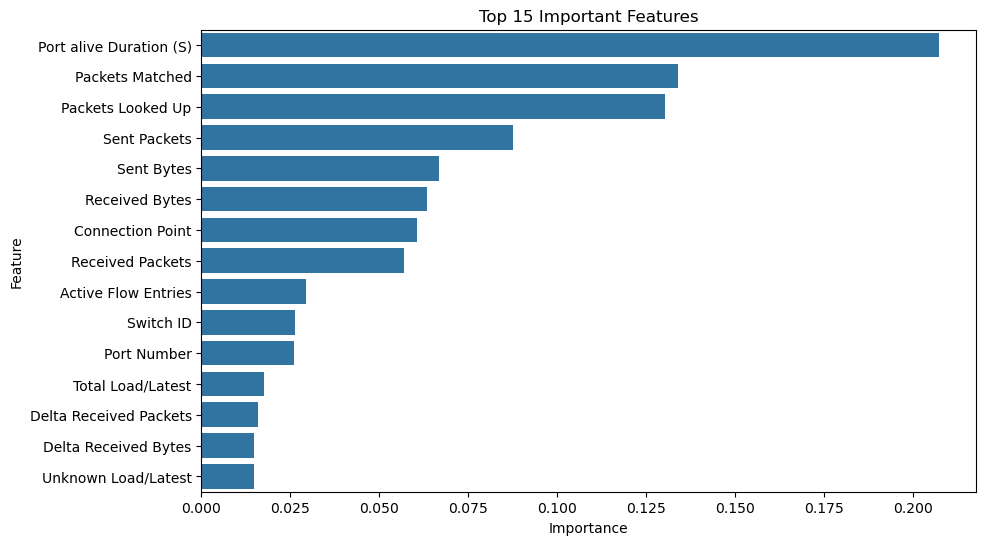

In [31]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance.head(15),
    x='Importance',
    y='Feature'
)

plt.title(
    "Top 15 Important Features"
)

plt.show()